# Capstone Project (Option 3)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
mall_data = pd.read_csv('Mall_Customers.csv')
mall_data_original = mall_data.copy()


In [23]:
# We begin by looking at the dataset

mall_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [24]:
# Next, we need to drop the columns that are of no use to KMeans Clustering.
# CustomerID has been removed as we can use our dataframe index instead of it.
# Gender has been dropped as categorical columns especially binary ones negatively effect KMeans clustering results, as it works best on continuous types of data.
# This is because KMeans works on the basis of measurement of relative distances of data points and binary columns skew that measurement.

mall_data = mall_data.drop(['CustomerID', 'Gender'], axis=1)
mall_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     200 non-null    int64
 1   Annual Income (k$)      200 non-null    int64
 2   Spending Score (1-100)  200 non-null    int64
dtypes: int64(3)
memory usage: 4.8 KB


Text(0.5, 1.0, 'Elbow Method')

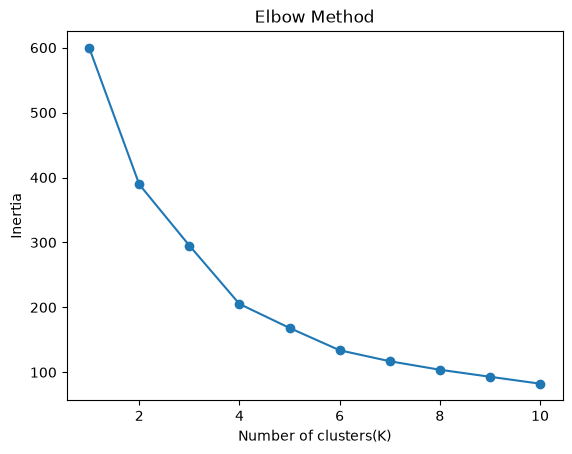

In [25]:
# Since there are no missing values in our feature columns, we can move on to scaling and fitting the model.
# In order to decide the no.of clusters to best split our data by, we will first use the elbow method.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


X = mall_data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(1,11)

for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters(K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

In [26]:
# Elbow method analysis points to clusters in the range of 4-6 to be optimum as beyond this decrease in inertia is not as meaningful.
# To make a final decision, let us check each of these possible values,
# For this we will analyse the mean values of our features in each cluster, when 4, 5 and 6 clusters are made to see how well data gets split each time.
# Finally, we will also look at the silhouette scores for different values of k, to further support our decision.

In [27]:
for k in [4,5,6]:
    km_check = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    label_check = km_check.fit_predict(X_scaled)
    mall_data_check = mall_data.copy()
    mall_data_check['Cluster'] = label_check
    print(f'\nk = {k}')
    print(mall_data_check.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))


k = 4
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        54.0                47.7                    40.0
1        32.9                86.1                    81.5
2        25.4                40.0                    60.3
3        39.4                86.5                    19.6

k = 5
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        46.2                26.8                    18.4
1        25.2                41.1                    62.2
2        32.9                86.1                    81.5
3        39.9                86.1                    19.4
4        55.6                54.4                    48.9

k = 6
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        56.3                54.3                    49.1
1        26.8                57.1                  

Text(0.5, 1.0, 'Silhouette Analysis')

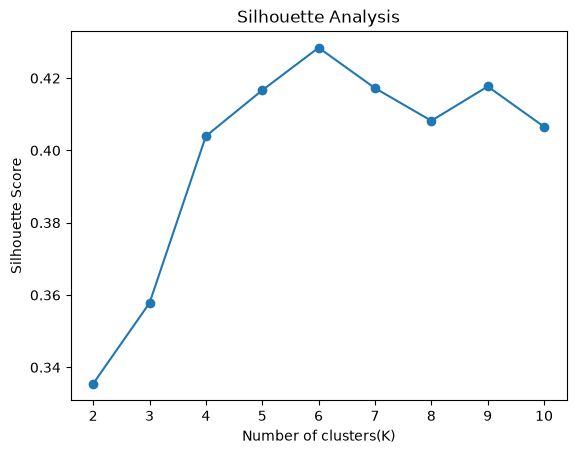

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2,11)

for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters(K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

In [29]:
# k = 6 seems to be the optimal value for no.of clusters to split this dataset.
# Looking at the mean feature values, k = 6 did not create any redundant clusters.
# It infact only introduced more meaningful categories that k = 4 and 5 were not able to capture.
# For example, the most unique one is Cluster 4 which includes young individuals with low income but extremely high spending.
# This is then further supported by k = 6 having the highest silhouette score amongst the tested values as well.
# This means that amongst the tested range, at k = 6,on average, points in each cluster are closest to their own centroids than other clusters' centroids,compared to other k value clusters' data points.
# This reflects decent splitting of dataset.

In [30]:
# Fitting the model with n_clusters = 6:

km_model = KMeans(n_clusters = 6, random_state = 42, n_init = 10)
km_model.fit(X_scaled)

Cluster = km_model.predict(X_scaled)

mall_data['Cluster Assigned'] = Cluster

In [31]:
mall_data.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster Assigned
0,19,15,39,4
1,21,15,81,4
2,20,16,6,5
3,23,16,77,4
4,31,17,40,5


Text(0.5, 1.0, 'Clusters by Income vs Spending Score')

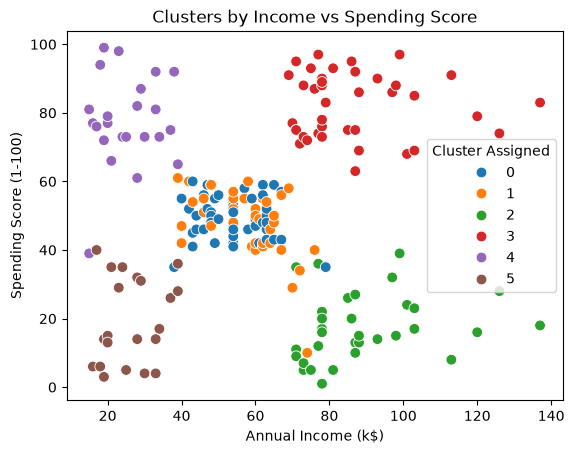

In [32]:
# Visualising clusters by Annual Income, Age and Spending Score:

sns.scatterplot(data = mall_data, x = 'Annual Income (k$)', y = 'Spending Score (1-100)',
               hue = 'Cluster Assigned', palette = 'tab10', s = 60)
plt.title('Clusters by Income vs Spending Score')

Text(0.5, 1.0, 'Clusters by Age vs Spending Score')

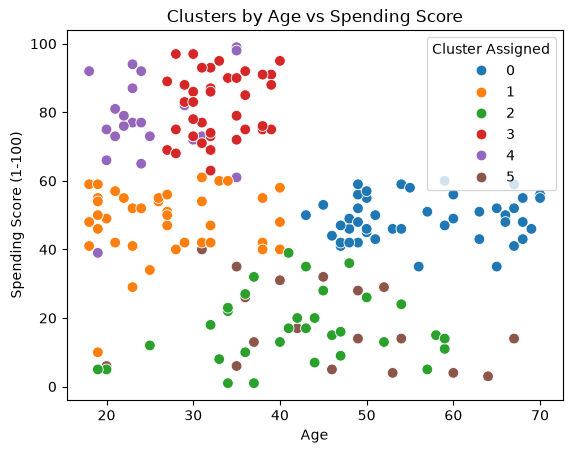

In [33]:
sns.scatterplot(data = mall_data, x = 'Age', y = 'Spending Score (1-100)',
               hue = 'Cluster Assigned', palette = 'tab10', s = 60)
plt.title('Clusters by Age vs Spending Score')

Text(0.5, 1.0, 'Clusters by Income vs Age')

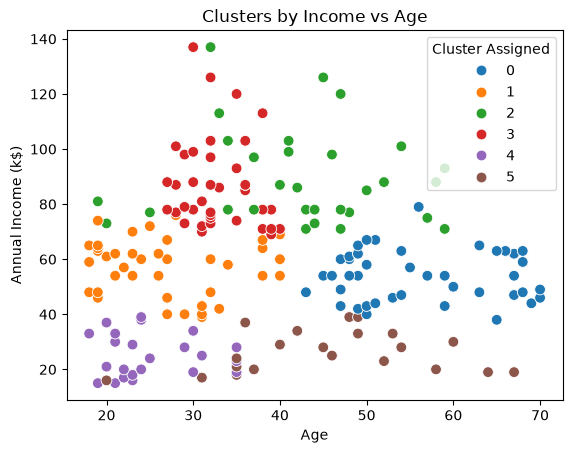

In [34]:
sns.scatterplot(data = mall_data, x = 'Age', y = 'Annual Income (k$)',
               hue = 'Cluster Assigned', palette = 'tab10', s = 60)
plt.title('Clusters by Income vs Age')

In [35]:
# Clusters seem to be decently separated.

In [36]:
# Now we can check if cluster sizes are balanced or not.
# We will also sort the clusters by mean spending score to assign labels.

summary = mall_data.groupby('Cluster Assigned').agg(
    Age = ('Age', 'mean'),
    Income = ('Annual Income (k$)', 'mean'),
    Spending = ('Spending Score (1-100)', 'mean'),
    Count = ('Cluster Assigned', 'size')
).round(1).sort_values('Spending')

summary

,Age,Income,Spending,Count
Cluster Assigned,,,,
2,41.9,88.9,17.0,33
5,45.5,26.3,19.4,21
1,26.8,57.1,48.1,39
0,56.3,54.3,49.1,45
4,25.0,25.3,77.6,23
3,32.7,86.5,82.1,39


In [37]:
# Create labels and final dataframes:

label_map = {
    2: 'Low Spender',
    5: 'Low Spender',
    1: 'Medium Spender',
    0: 'Medium Spender',
    4: 'High Spender', 
    3: 'High Spender'
}

mall_data_original['Cluster Assigned'] = Cluster
mall_data_original['Label'] = mall_data_original['Cluster Assigned'].map(label_map)
summary['Label'] = summary.index.map(label_map)


In [42]:
# Original dataset now complete with each customer labelled as high, medium or low spender.

mall_data_original.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Assigned,Label
0,1,Male,19,15,39,4,High Spender
1,2,Male,21,15,81,4,High Spender
2,3,Female,20,16,6,5,Low Spender
3,4,Female,23,16,77,4,High Spender
4,5,Female,31,17,40,5,Low Spender


In [43]:
summary

,Age,Income,Spending,Count,Label
Cluster Assigned,,,,,
2,41.9,88.9,17.0,33,Low Spender
5,45.5,26.3,19.4,21,Low Spender
1,26.8,57.1,48.1,39,Medium Spender
0,56.3,54.3,49.1,45,Medium Spender
4,25.0,25.3,77.6,23,High Spender
3,32.7,86.5,82.1,39,High Spender


In [44]:
# Additional cross tab to show proportion of male and female customers in each cluster.

pd.crosstab(mall_data_original['Cluster Assigned'], mall_data_original['Gender'])

Gender,Female,Male
Cluster Assigned,,
0,26,19
1,25,14
2,14,19
3,21,18
4,13,10
5,13,8


# Practice Questions:

In [64]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [52]:
data = pd.read_csv('data.csv')
data_original = data.copy()
data_original.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [53]:
data_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [54]:
data = data.drop(['id', 'Unnamed: 32'], axis = 1)
data['diagnosis'] = data['diagnosis'].map({'M' : 1, 'B': 0})

In [55]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [57]:
X = data.drop(columns = ['diagnosis'])
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42, stratify = y)


In [58]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

In [60]:
# Question 1:

cv_scores = cross_val_score(pipe, X_train, y_train, cv = 5, scoring = 'accuracy')
print('Cross validation scores:', cv_scores)
print('Mean CV accuracy:', cv_scores.mean())

Cross validation scores: [0.96703297 1.         0.96703297 0.96703297 0.96703297]
Mean CV accuracy: 0.9736263736263737


In [61]:
# Question 2: 

param_grid = {
    'svm__C': [0.1,1,10,100],
    'svm__gamma': [1,0.1,0.01,0.001],
    'svm__kernel': ['rbf', 'linear']
}

grid = GridSearchCV(pipe, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
grid.fit(X_train, y_train)

print('\nBest parameters:', grid.best_params_)
print('\nBest CV accuracy:', grid.best_score_)


Best parameters: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

Best CV accuracy: 0.9736263736263737


In [62]:
best_model = grid.best_estimator_

In [66]:
y_pred = best_model.predict(X_test)

print('\nTest set performance:')

print(f'Accuracy: {accuracy_score(y_test,y_pred)}')

print(classification_report(y_test, y_pred))

print(f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}')



Test set performance:
Accuracy: 0.9824561403508771
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[72  0]
 [ 2 40]]


In [67]:
# Question 3:

joblib.dump(best_model, 'svm_breast_cancer_model.joblib')

['svm_breast_cancer_model.joblib']

In [68]:
# Question 4:

loaded_model = joblib.load('svm_breast_cancer_model.joblib')

new_data = pd.DataFrame([[12.45, 15.70, 82.57, 477.1, 0.1278, 0.17, 0.1578, 0.08089, 0.2087, 0.07613,
    0.3345, 0.8902, 2.217, 27.19, 0.00751, 0.03345, 0.03672, 0.01137, 0.02165, 0.005082,
    15.47, 23.75, 103.4, 741.6, 0.1791, 0.5249, 0.5355, 0.1741, 0.3985, 0.1244]], columns = X.columns)


In [71]:
predictions = loaded_model.predict(new_data)

print('Prediction:', predictions)

Prediction: [1]
